# 2.1 Linear Regression
"Begin at the beginning"

Math notation (LATEX) inside Markdown: https://www.upyesp.org/posts/makrdown-vscode-math-notation/

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

Acquire the Data Set

In [2]:
# 
data = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv"
!wget $data

--2026-10-05 18:00:09--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.1’

data.csv.1          100%[===================>]   1.41M  --.-KB/s    in 0.007s  

2026-10-05 18:00:09 (200 MB/s) - ‘data.csv.1’ saved [1475504/1475504]



In [18]:
df = pd.read_csv('data.csv')

In [19]:
len(df)

11914

In [20]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## 2.2 Data Preparation
Make inconsistent headers consistent

In [21]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

Inconsistent Data
Find out what the types of data is, using dtypes. We are interested in 'object' data
In my case, they are actually 'str' data.

In [22]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [23]:
df.dtypes[df.dtypes == "str"]

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

To get access to the names, we use 'index'. We convert it to a list just because it looks nice. And we name it "strings".

In [24]:
strings = list(df.dtypes[df.dtypes == "str"].index)

Loop over each column, convert to lower case, replace spac

In [25]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [26]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


## 2.3 Exploratory Data Analysis

In [27]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

### A look at price distribution

In [ ]:
# This was already done in cell 1
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

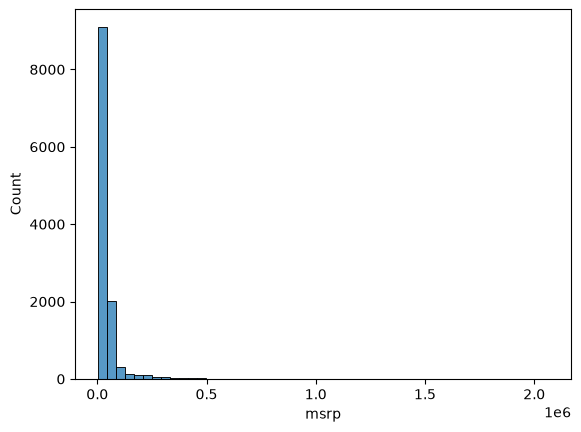

In [28]:
sns.histplot(df.msrp, bins=50)

`bins` is the size of the bars. `1e6` is 10^6 which is 1,000,000 one million.
    This is a long-tailed distribution. 

<Axes: xlabel='msrp', ylabel='Count'>

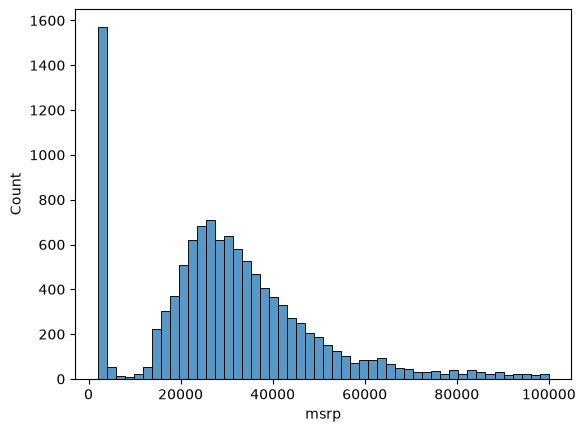

In [29]:
sns.histplot(df.msrp[df.msrp < 100_000], bins=50)

We apply the logarithmic distribution to get rid of the long tail. For logaritms, it is common to add one so that we are not seeking the log of zero (0)

In [30]:
np.log([1, 10, 1000, 100000])

array([ 0.        ,  2.30258509,  6.90775528, 11.51292546])

In [31]:
np.log([0, 1, 10, 1000, 100000])

/tmp/ipykernel_4359/1040805571.py:1: RuntimeWarning: divide by zero encountered in log
  np.log([0, 1, 10, 1000, 100000])


array([       -inf,  0.        ,  2.30258509,  6.90775528, 11.51292546])

Adding one (1) to each value can avoid this situation.

In [32]:
np.log1p([0, 1, 10, 1000, 100000 ])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

<Axes: xlabel='msrp', ylabel='Count'>

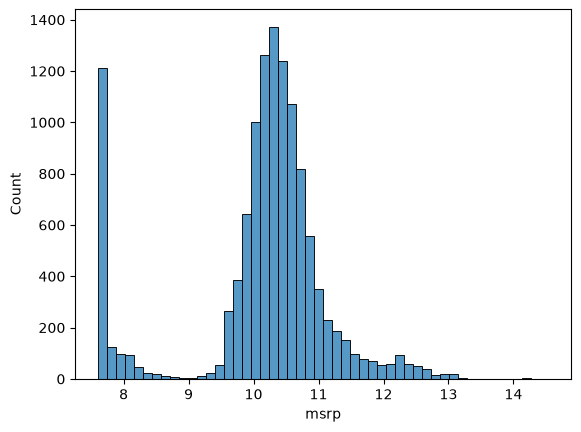

In [33]:
price_logs = np.log1p(df.msrp)
sns.histplot(price_logs, bins=50)

This is closer to the bell curve shape, which is also called a "normal distribution" (with the exception of the 1000$ peak). The normal distribution is ideal for models. Long tail distributions normally confuse models.

In [ ]:
### Missing Values

In [34]:
df.isnull()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11910,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11911,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11912,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [35]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## 2.4 Setting up the Validation Framework

For validating the model, we need to take our data set, and split into three parts:
1. Training X<sub>T</sub>y<sub>T</sub> , 60%
2. Validation X<sub>V</sub>y<sub>T</sub> 20%
3. Test X<sub>TEST</sub>y<sub>TEST</sub> 20%

We will beging by calculating how much 20% actually is.

In [36]:
len(df) # the size of our dataframe

11914

In [37]:
int(len(df) * 0.2)

2382

In [38]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = int(n * 0.6)

In [39]:
n, n_val + n_test + n_train

(11914, 11912)

We don't want to accidentally leave a few records

In [40]:
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

n, n_val + n_test + n_train

(11914, 11914)

In [41]:
n_val, n_test, n_train

(2382, 2382, 7150)

Use `iloc` to create the subsets

In [42]:
df.iloc[11910:]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920
11913,lincoln,zephyr,2006,regular_unleaded,221.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,26,17,61,28995


In [43]:
df_val = df.iloc[:n_val]
df_test = df.iloc[n_val:n_val + n_test]
df_train = df.iloc[n_val + n_test:]

In [44]:
df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


We need to shuffle the records to make sure that, for example, there are bmws in all three data sets.

In [45]:
np.arange(n)

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [46]:
idx = np.arange(n)
np.random.seed(2) # set the random seed for reproducibility and consistency across sessions
np.random.shuffle(idx)
idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [47]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [48]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
1902,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
9334,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
5284,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


In [49]:
df_train = df_train.reset_index(drop=True)

In [50]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


In [51]:
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

For training and validation, we use Numpy values rather than Pandas values.

In [52]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

The last thing we do in the validation segment is do remove the msrp variable from our dataframe. This avoids the case where we accidentially use these values in our training run.

So after splitting the data, remove the target variable from the data frame, to make sure that we do not accidentally use it for training purposes.

In [53]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

## 2.5 Linear Regression

In [54]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

We will take engine_hp, city_mpg, and popularity. This is our feature matrix.

In [13]:
xi = [453, 11, 86]

In [14]:
# this will be our linear regression
def g(xi):
    # do something
    return 10_000

In [15]:
g(xi)

10000

In [63]:
xi = [453, 11, 86]

g(xi) ~ yi

g(xi) = W<sub>0</sub> + W<sub>1</sub> * x<sub>i1</sub> + W<sub>2</sub> * x<sub>i2</sub> + W<sub>3<sub> * x<sub>i3</sub>

g(xi) = W<sub>0</sub> + SUM j=1 to 3 for W<sub>j</sub> * x<sub>ij</sub>

in code:

In [57]:
w0 = 0
w = [1, 1, 1]

This is our simple linear regression: For every element in our feature vector, we multiply it by the corresponding weight, and then everything is assigned to the prediction. At the end, the prediction is the sum of as represented by the sigma formula above.

In [58]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]
    return pred

In [59]:
linear_regression(xi)

550

In [60]:
w0 = 7.17 # bias term
w = [0.01, 0.04, 0.002] # weights

In [61]:
linear_regression(xi)

12.312

### From log price back to dollars
12.312 is not the price in dollars, but rather the logarithm of the price. Previously, log1p() was used to deal with the long tail distribution. To undo the logarithm find the exponent.

In [62]:
np.expm1(12.312)

np.float64(222347.2221101062)

Thus the predicted price is 222,347 USD. Rule of thumb is to appy np.expm1() after using np.log1p(), as its inverse.

In [63]:
np.log1p(222347.2221101062)

np.float64(12.312)

## 2.6 Linear Regression: Vector Form

g(xi) = W<sub>0</sub> + SUM j=1 to 3 for W<sub>j</sub> * x<sub>ij</sub> is a dot product (vector x vector multiplication)

$$
\displaystyle\sum_{j=3}^3 W_{j} * x_{i,j}
$$

$g(x_{i}) = W_{0} + x_{i}^T * W$ 

T indicates Transpose 
W indicates weights vector

In [5]:
def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] + w[j]

    return res

In [6]:
def linear_regression(xi):
    return w0 + dot(xi, w)

### The Fictional Feature

In [65]:
# our new vector with weights
# 1 gets added to w0, so w0 (which presently is 0) is effectively 1
w_new = [w0] + w

In [66]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [67]:
def linear_regression(xi):
    xi = [1] + xi
    return np.dot(xi, w_new)

In [68]:
linear_regression(xi)

np.float64(12.312)

### Linear Regression on All Cars

Three cars are prepended one to each feature vector, then combined into one matrix, which is then converted into a NumPy array.

In [70]:
x1 = [1, 148, 24, 1385]
x2 = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)

In [71]:
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

Multiply this matrix with this vector, using the dot() method.

In [77]:
def linear_regression(X):
    return X.dot(w_new)

In [79]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

In [80]:
price = np.expm1(linear_regression(X))

In [81]:
price

array([237992.82334859, 768348.51018973, 222347.22211011])

In this lesson we applied a linear regression model when we already have the weights. The next question is, where do the weights come from?

## 2.7 Training Linear Regression: Normal Equation

We derive the normal equation as a closed-form formula for the weights, and then implement it as a `train_linear_regression` function.

### Solving for the Weights

We have the matrix $X$, and we want the predction $g(X) \approx X_{w}$ to be as close to the actual values for $y$.

$X_{w} \approx y$

Ideally, $X_{w}$ equals $y$ exactly, and we can try to solve this system for $w$.

Supposing that $X$ is invertible, there exists a matrix $X^{-1}$ such that $X^{-1}X$ is the identity matrix $I$. Then we can multiply both sideds of the equation by $X^{-1}$:

$X^{-1}X_{w} = X^{-1}y$

$I_{w} = X^{-1}y$

$w = X^{-1}y$

However, there is a problem because $X$ is a rectangular matrix, and is not square. $X$ has $m$ rows (one per car) and $n + 1$ columns (one per feature, plus the bias term). In our dataset $m$ is much larger than $n + 1$, and the matrix is not square. As only square matrices can have an inverse, the solution to this system does not exist.

### Gram Matrix and the Normal Equation

Even though the excact solution does not exist, we can find the closest possible approximate solution, by multiplying both sides of $X_{w} \approx y$ by the transpose of $X$:

$X^{T}X_{w} = X^{T}y$

The matrix $X^{T}X$ is called the Gram matrix.

$w = (X^{T}X)^{-1}X^{T}y$

GRAM MATRIX
$(n + 1) x (n + 1)$

Unlike $X$, the Gram matrix is square: It has $n + 1$ rows and $n + 1$ columns. Square matrices usually have an inverse, so we can multiply both sides by $(X^{T}X)^{-1}$:

$(X^{T}X)^{-1}X^{T}X_{w} = (X^{T}X)^{-1}X^{T}y$

On the left, $(X^{T}X)^{-1}X^{T}X$ is the identity matrix, and $I_{w} = w$. This leaves us with:

$w = (X^{T}X)^{-1}X^{T}y$

$I_{w} = w$

This $w$ is not the solution to the original system, but it is the closest possible solution.

### Implementing the Normal Equation

We will implement this formula step-by-step in NumPy, using a small toy matrix to keep things simple.

In [3]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)

The first step of the normal equation is the Gram matrix:

In [4]:
XTX = X.T.dot(X)

Then its inverse:

In [5]:
XTX_inv = np.linalg.inv(XTX)